In [10]:
import lovelyplots
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import tqdm, trange
from weylchamber import c1c2c3

from gulps import logger
from gulps.core.coverage import coverage_report
from gulps.core.invariants import GateInvariants
from gulps.core.isa import ISAInvariants
from gulps.gulps_decomposer import GulpsDecomposer
from gulps.viz.invariant_viz import render_path

### Usage as a Decomposer

In [11]:
# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (CXGate().power(1 / 6), 1 / 6, "sqrt6cx"),
    # (iSwapGate(), 1.0, "iswap"),
    # (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    # (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    (iSwapGate().power(1 / 6), 1 / 6, "sqrt6iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 1.0, "swap"),
    # (SwapGate().power(1 / 2), 1 / 2, "eswap"),
    # (SwapGate().power(1 / 3), 1 / 3, "eswap"),
]
gate_set, costs, names = zip(*isa)
isa = ISAInvariants(gate_set, costs, names, precompute_polytopes=False)
decomposer = GulpsDecomposer(isa=isa)

In [12]:
if hasattr(decomposer.isa, "coverage_set"):
    report = coverage_report(decomposer.isa.coverage_set)

In [13]:
logger.setLevel("INFO")
N = 1_000

# Warm-start to trigger JIT compilation (optional)
_ = decomposer(random_unitary(4, seed=0))

fidelities = []
all_timings = []
failures = 0

for idx in trange(N, desc="Decomposing random unitaries"):
    u = random_unitary(4, seed=idx)
    try:
        v = Operator(decomposer(u))
        fid = average_gate_fidelity(u, v)

        if fid < 1 - 1e-8:
            raise ValueError(f"Fidelity too low: {fid:.8f}")

        fidelities.append(fid)
        all_timings.append(decomposer.last_timing)

    except Exception as e:
        print(f"[WARN] Failed on unitary {idx}: {e}")
        failures += 1

# === Fidelity Statistics ===
fidelities = np.array(fidelities)
print(f"\n✔ Completed {len(fidelities)} successful runs (out of {N})")
print(f"  → Failures: {failures}")
print(f"  → Median Fidelity: {np.median(fidelities)}")
print(f"  → Mean Fidelity:   {np.mean(fidelities)}")
print(f"  → Min Fidelity:    {np.min(fidelities)}")

# === Timing Statistics ===
if all_timings:
    phase_names = list(all_timings[0].keys())
    timing_array = np.array([[t[k] for k in phase_names] for t in all_timings])

    print("\nAverage phase durations:")
    for k, mean_time in zip(phase_names, timing_array.mean(axis=0)):
        print(f"  {k:>10}: {mean_time:.4f} s")

    print(f"\n  Total average time: {timing_array.sum(axis=1).mean():.4f} s")
else:
    print("No successful timings collected.")

Decomposing random unitaries:  18%|█▊        | 182/1000 [00:13<00:52, 15.67it/s]

[WARN] Failed on unitary 179: Cannot recover local equivalence; Weyl differences [2.07096508e-05 2.04109884e-05 2.95898628e-07]


Decomposing random unitaries:  21%|██▏       | 214/1000 [00:15<00:58, 13.53it/s]

[WARN] Failed on unitary 210: Cannot recover local equivalence; Weyl differences [1.06750431e-09 1.82092122e-05 1.82083244e-05]


Decomposing random unitaries:  24%|██▍       | 238/1000 [00:17<00:53, 14.13it/s]

...

[WARN] Failed on unitary 854: Cannot recover local equivalence; Weyl differences [3.18515170e-09 3.21355668e-05 3.21390651e-05]


Decomposing random unitaries:  91%|█████████ | 910/1000 [01:07<00:05, 15.32it/s]

[WARN] Failed on unitary 906: Cannot recover local equivalence; Weyl differences [3.46848772e-10 1.32149656e-05 1.32152929e-05]


Decomposing random unitaries: 100%|██████████| 1000/1000 [01:14<00:00, 13.45it/s]


✔ Completed 987 successful runs (out of 1000)
  → Failures: 13
  → Median Fidelity: 0.9999999999999793
  → Mean Fidelity:   0.9999999999956296
  → Min Fidelity:    0.9999999996886755

Average phase durations:
  lp_sentence: 0.0057 s
    segments: 0.0665 s

  Total average time: 0.0722 s


In [14]:
decomposer(random_unitary(4, seed=705))

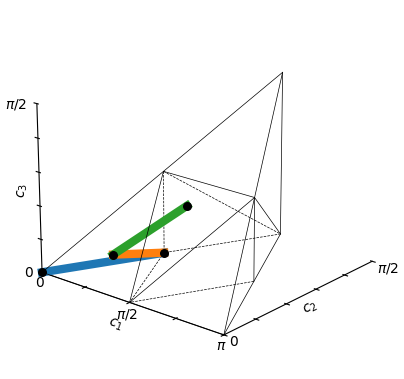

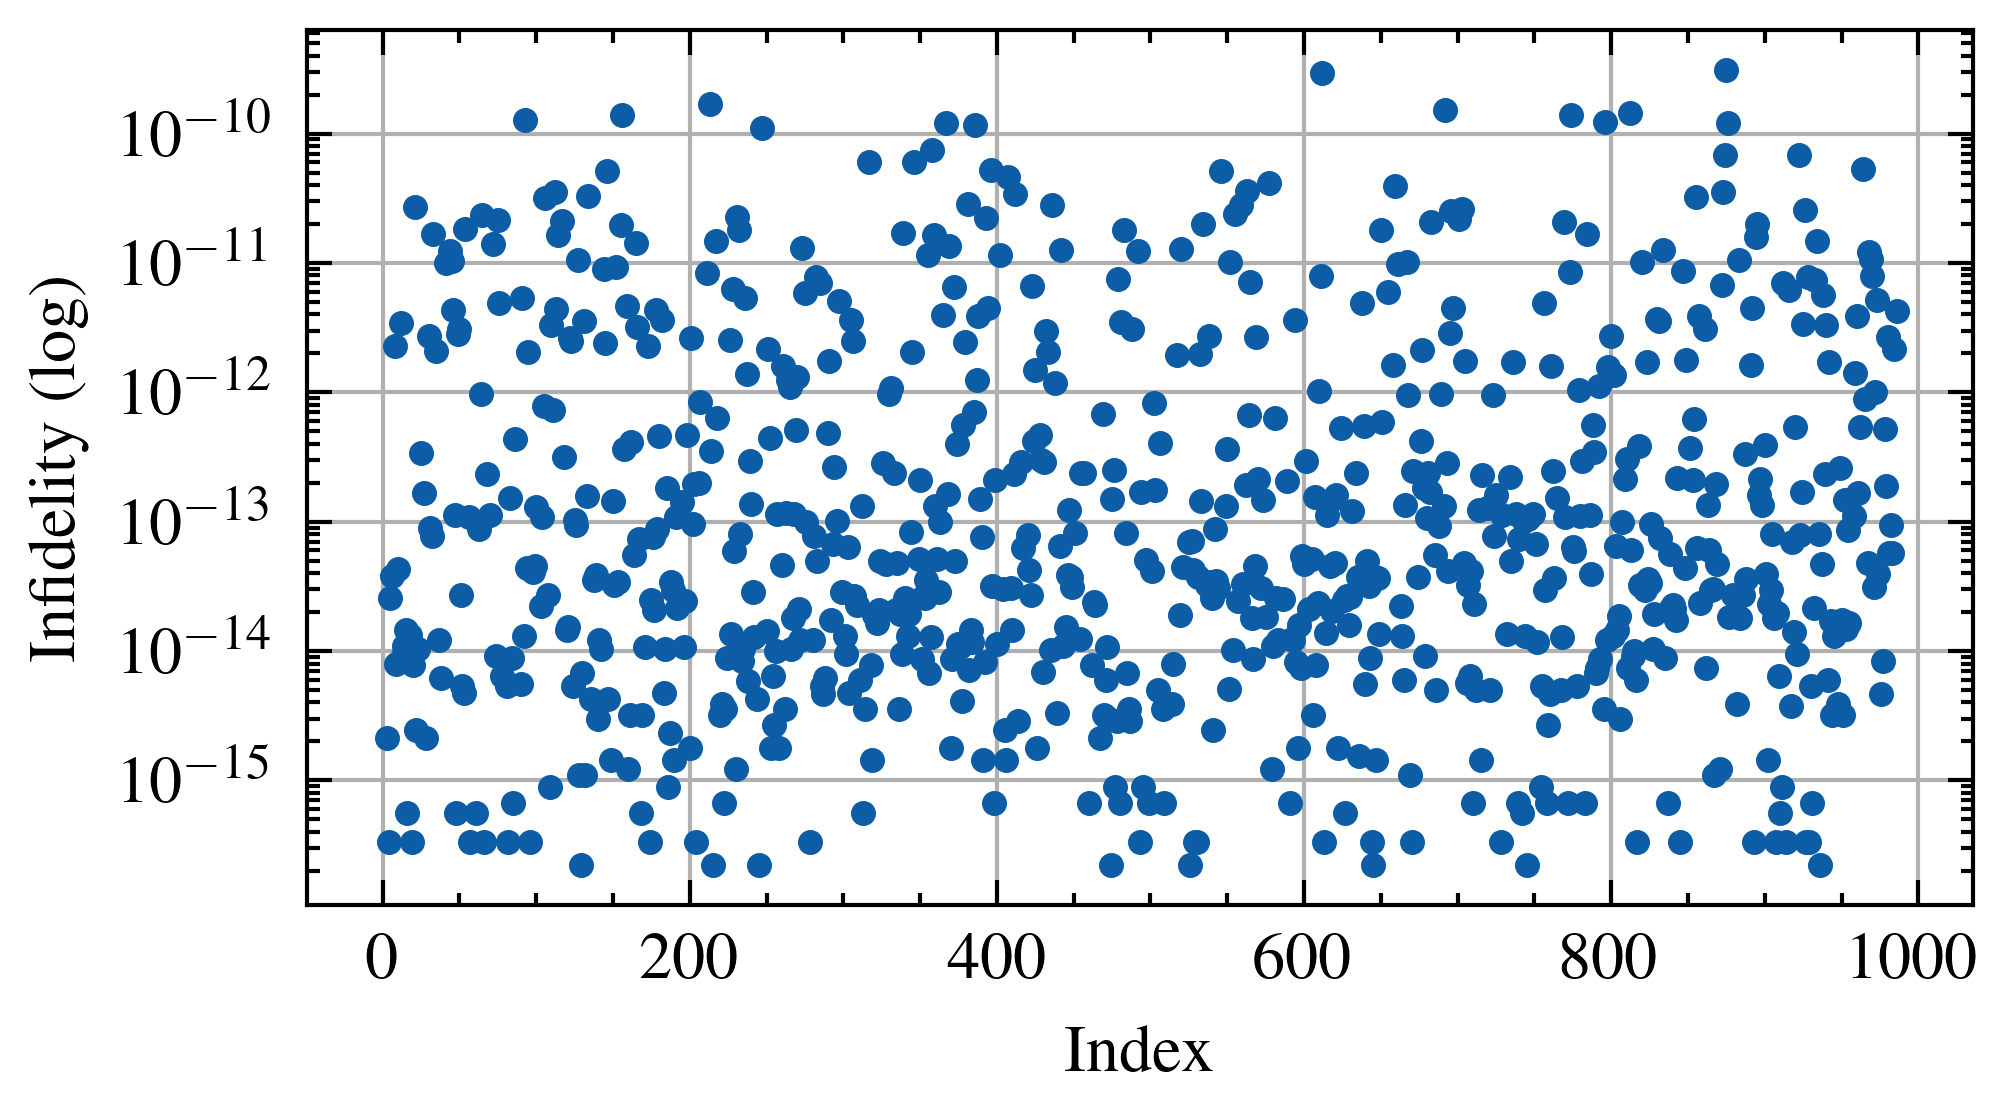

In [15]:
# make a plot for the fidelities
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, ax = plt.subplots(figsize=(3.5, 2))
    ax.plot(1 - fidelities, marker="o", markersize=2, linestyle="None")
    ax.set_xlabel("Index")
    ax.set_ylabel("Infidelity (log)")
    ax.set_yscale("log")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

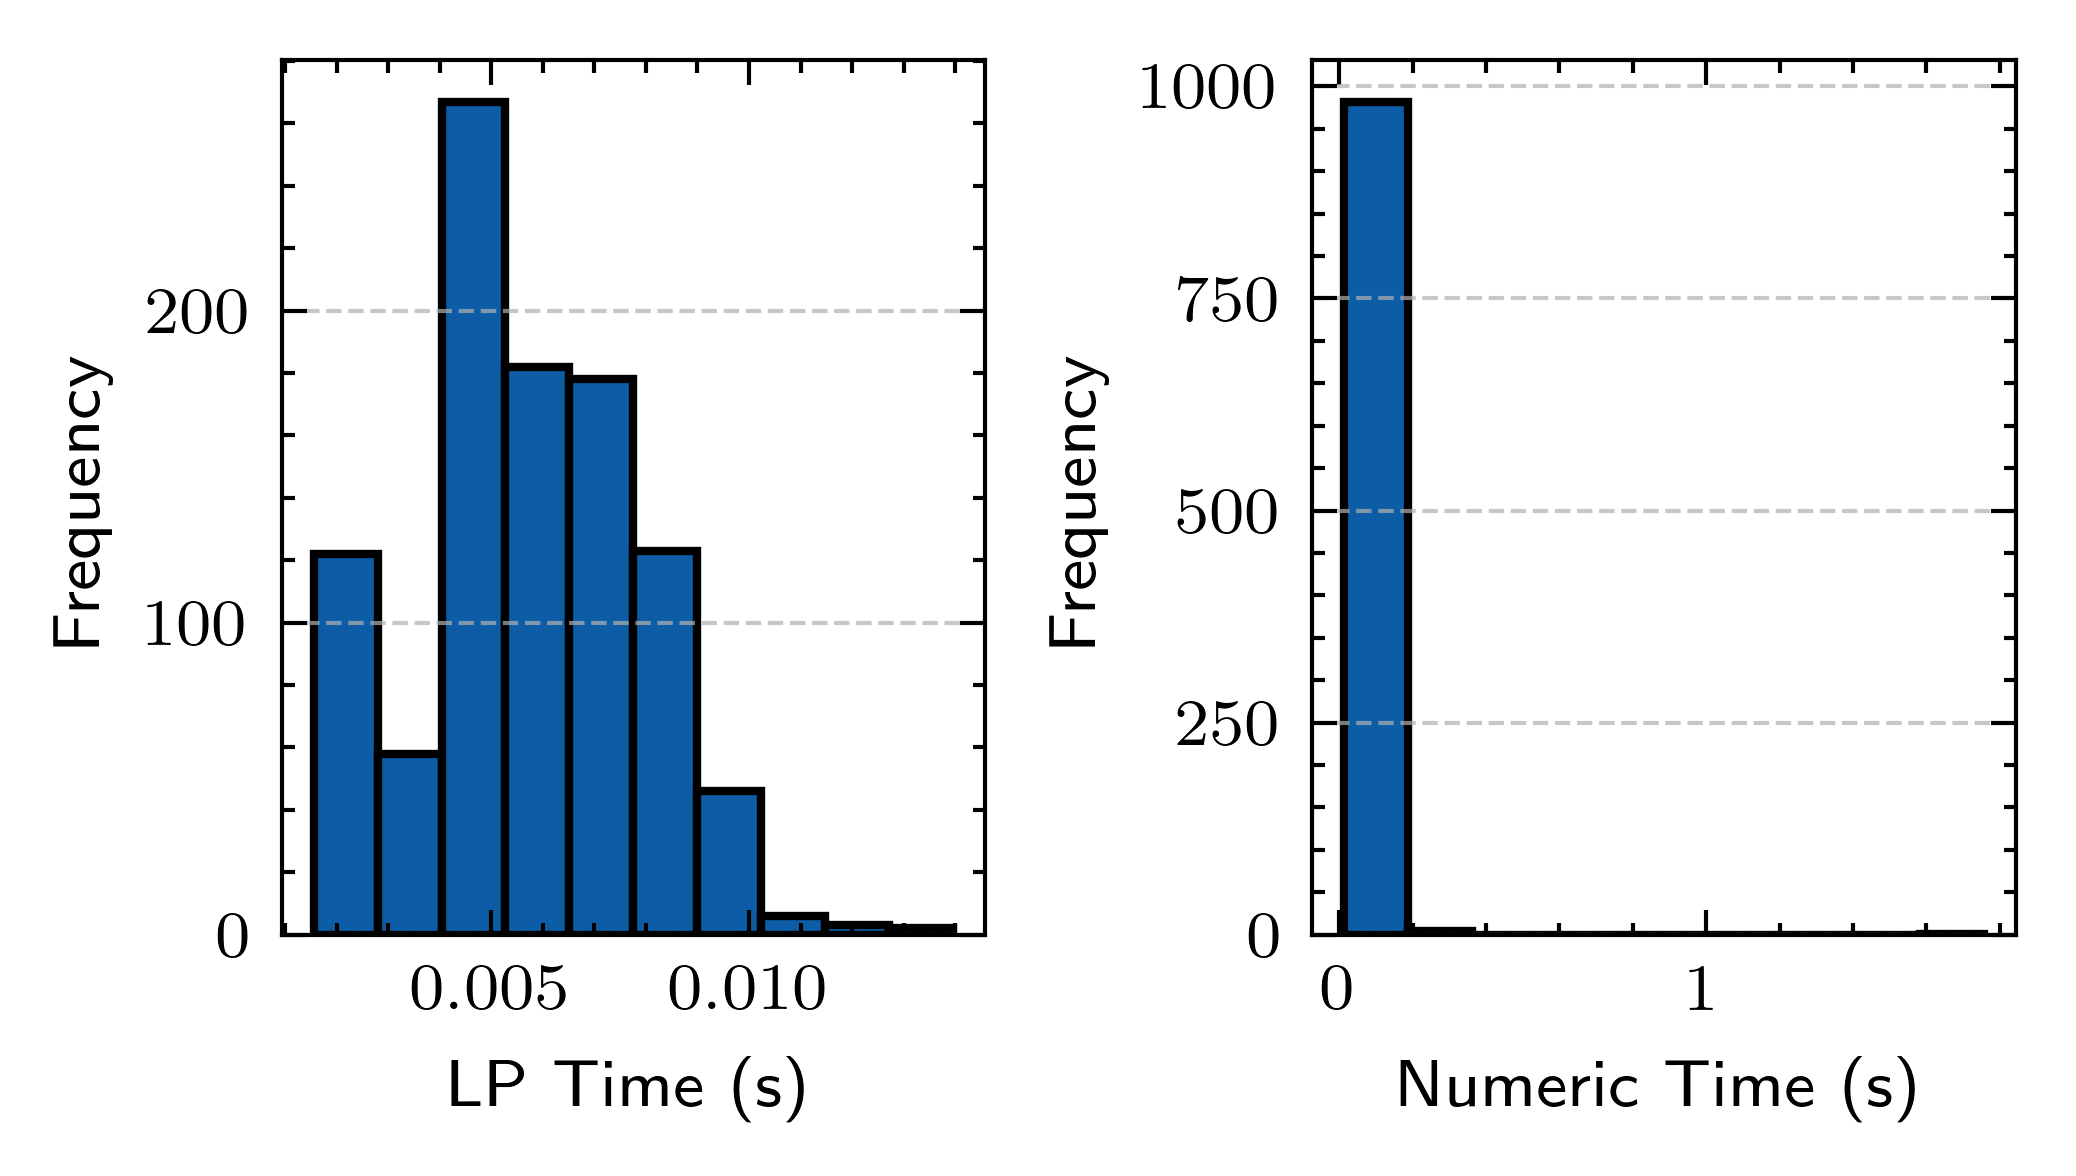

In [16]:
# Convert list of dicts to lists of values
lp_times = [d["lp_sentence"] for d in all_timings]
numeric_times = [d["segments"] for d in all_timings]

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 2, figsize=(3.5, 2))

    axes[0].set_xlabel("LP Time (s)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)
    axes[0].hist(lp_times, edgecolor="black")

    axes[1].set_xlabel("Numeric Time (s)")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(axis="y", linestyle="--", alpha=0.7)
    axes[1].hist(numeric_times, edgecolor="black")

    fig.tight_layout()
plt.show()

#### Inspecting the pieces

In [17]:
example_input = random_unitary(4, seed=0)
example_target = GateInvariants.from_unitary(example_input, enforce_alcove=True)
example_sentence, example_intermediates = decomposer._best_decomposition(
    target_inv=example_target
)
render_path(example_intermediates);

In [18]:
example_segment_solutions = decomposer._local_synthesis.synthesize_segments(
    example_sentence, example_intermediates, example_target
)
example_segment_solutions.draw()

global phase: 5.1451
     ┌─────────┐┌──────────┐┌─────────┐┌──────────┐┌─────────┐┌─────────┐»
q_0: ┤ Unitary ├┤0         ├┤ Unitary ├┤0         ├┤ Unitary ├┤ Unitary ├»
     ├─────────┤│  Unitary │├─────────┤│  Unitary │├─────────┤├─────────┤»
q_1: ┤ Unitary ├┤1         ├┤ Unitary ├┤1         ├┤ Unitary ├┤ Unitary ├»
     └─────────┘└──────────┘└─────────┘└──────────┘└─────────┘└─────────┘»
«     ┌──────────┐┌─────────┐┌─────────┐┌──────────┐┌─────────┐┌─────────┐»
«q_0: ┤0         ├┤ Unitary ├┤ Unitary ├┤0         ├┤ Unitary ├┤ Unitary ├»
«     │  Unitary │├─────────┤├─────────┤│  Unitary │├─────────┤├─────────┤»
«q_1: ┤1         ├┤ Unitary ├┤ Unitary ├┤1         ├┤ Unitary ├┤ Unitary ├»
«     └──────────┘└─────────┘└─────────┘└──────────┘└─────────┘└─────────┘»
«     ┌──────────┐┌─────────┐
«q_0: ┤0         ├┤ Unitary ├
«     │  Unitary │├─────────┤
«q_1: ┤1         ├┤ Unitary ├
«     └──────────┘└─────────┘